# PCA with histogram

created: 2/14/2026

van

In [18]:
import os
import sys
from glob import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sb
import pytraj as pt


In [2]:

os.makedirs('img', exist_ok=True)
os.makedirs('pca', exist_ok=True)


In [10]:
# select systems for analysis

dnames = ["wt", "r918a", "r918k"]
# dnames = ["wt", "r921a", "r921k"]


In [11]:
# set vars 

# convert dnames to join string
dn = '_'.join(str(dname) for dname in dnames) 
os.makedirs(f'pca/{dn}', exist_ok=True)

parm = "step3_pbcsetup_1264.parm7"
cord = "prod*.nc"

# Atom mask selection
res_mask = ":909-1076,1404-1410"
atm_mask = "@CA,C,N,O,P,O5',O3',OP1,OP2,C1',C2',C3',C4',C5'"
# atm_mask = '@CA'
ambermask = f'{res_mask}&{atm_mask}'

clean_ambermask = re.sub(r'[^a-zA-Z0-9]', '_', ambermask)

analysis=f'mask{clean_ambermask}'

print('save name: ', analysis)
print('mask selection:', ambermask)

# change this to change number of prod files
n_cords = 11



save name:  mask_909_1076_1404_1410__CA_C_N_O_P_O5__O3__OP1_OP2_C1__C2__C3__C4__C5_
mask selection: :909-1076,1404-1410&@CA,C,N,O,P,O5',O3',OP1,OP2,C1',C2',C3',C4',C5'


In [12]:
# get trajectories, strip atoms, save new trajectory/parm


label_idx = [] # save frames here to iterate in scatter

for dname in dnames:
    nc_files = sorted(glob(f'../{dname}/{cord}'))[n_cords:] 
    t1 = pt.iterload(nc_files, f'../{dname}/{parm}')
    t1 = pt.superpose(t1, mask=ambermask)

    # Strip everything not in atommask and save new trajectory
    t1_strip = pt.strip(t1, f'!({ambermask})')
    label_idx.append(t1_strip.n_frames)
    nframes = str(t1_strip.n_frames)
    
    out_dir = f'pca/{dn}/{nframes}/{analysis}'
    os.makedirs(out_dir, exist_ok=True)
    t1_strip.save(f'{out_dir}/{dname}.nc', overwrite=True)
    
    print('fnames: ', nc_files)
    print('traj frames/atoms: ', t1.n_frames, 'frames / ', t1.n_atoms, 'atoms')
    print('stripped info: ', t1_strip.n_frames, 'frames /', t1_strip.n_atoms, 'atoms', f'\n')


n = '_'.join(str(num) for num in label_idx) # convert int list to join string

combine_out = f'pca/{dn}/{n}/{analysis}'
os.makedirs(combine_out, exist_ok=True)
combined_name = f'{combine_out}/step3'

# save stripped parm
top_keep = pt.strip(t1.top, f'!({ambermask})')
pt.save(f'{combined_name}.parm7', top_keep, overwrite=True)

# save stripped combined traj
fnames= [fn for dname in dnames for fn in glob(f'pca/{dn}/{nframes}/{analysis}/{dname}.nc')] # find the correct files
traj = pt.iterload(fnames, top_keep)
traj = pt.superpose(traj, mask=atm_mask, ref=0)
print('combined stripped info: ', traj)

# save stripped trajectory
pt.save(f'{combined_name}.nc', traj, overwrite=True)

print('combined parm: ', f'{combined_name}.parm7')
print('combined traj: ', f'{combined_name}.nc')


fnames:  ['../wt/prod11.nc', '../wt/prod12.nc', '../wt/prod13.nc', '../wt/prod14.nc']
traj frames/atoms:  199 frames /  359487 atoms
stripped info:  199 frames / 742 atoms 

fnames:  ['../r918a/prod11.nc', '../r918a/prod12.nc', '../r918a/prod13.nc', '../r918a/prod14.nc']
traj frames/atoms:  199 frames /  359477 atoms
stripped info:  199 frames / 742 atoms 

fnames:  ['../r918k/prod11.nc', '../r918k/prod12.nc', '../r918k/prod13.nc', '../r918k/prod14.nc']
traj frames/atoms:  199 frames /  359491 atoms
stripped info:  199 frames / 742 atoms 

combined stripped info:  pytraj.TrajectoryIterator, 597 frames: 
Size: 0.009901 (GB)
<Topology: 742 atoms, 175 residues, 2 mols, PBC with box type = orthorhombic>
           
combined parm:  pca/wt_r918a_r918k/199_199_199/mask_909_1076_1404_1410__CA_C_N_O_P_O5__O3__OP1_OP2_C1__C2__C3__C4__C5_/step3.parm7
combined traj:  pca/wt_r918a_r918k/199_199_199/mask_909_1076_1404_1410__CA_C_N_O_P_O5__O3__OP1_OP2_C1__C2__C3__C4__C5_/step3.nc


In [21]:
# run PCA

n_vectors = 10 # set this for cpptraj later

traj = pt.iterload(f'{combined_name}.nc', f'{combined_name}.parm7')
data = pt.pca(traj, mask=atm_mask, n_vecs=n_vectors)

print(traj)

pytraj.TrajectoryIterator, 597 frames: 
Size: 0.009901 (GB)
<Topology: 742 atoms, 175 residues, 2 mols, PBC with box type = orthorhombic>
           


In [20]:
# Get variance of PCs / flip data

pc_eval = data[1][0]   # eigenvalues (or variance) for PC1
x_label = (pc_eval[0] / np.sum(pc_eval)) * 100 # percent variance for pc1
y_label = (pc_eval[1] / np.sum(pc_eval)) * 100 # percent variance for pc2

flip1, flip2 = -1, 1 # incase the axis needs to be flipped
x_data = data[0][0] * flip1
y_data = data[0][1] * flip2

print('PC1 variance (%): ', x_label)
print('PC2 variance (%): ', y_label)


PC1 variance (%):  47.406798153877
PC2 variance (%):  34.950780908438524


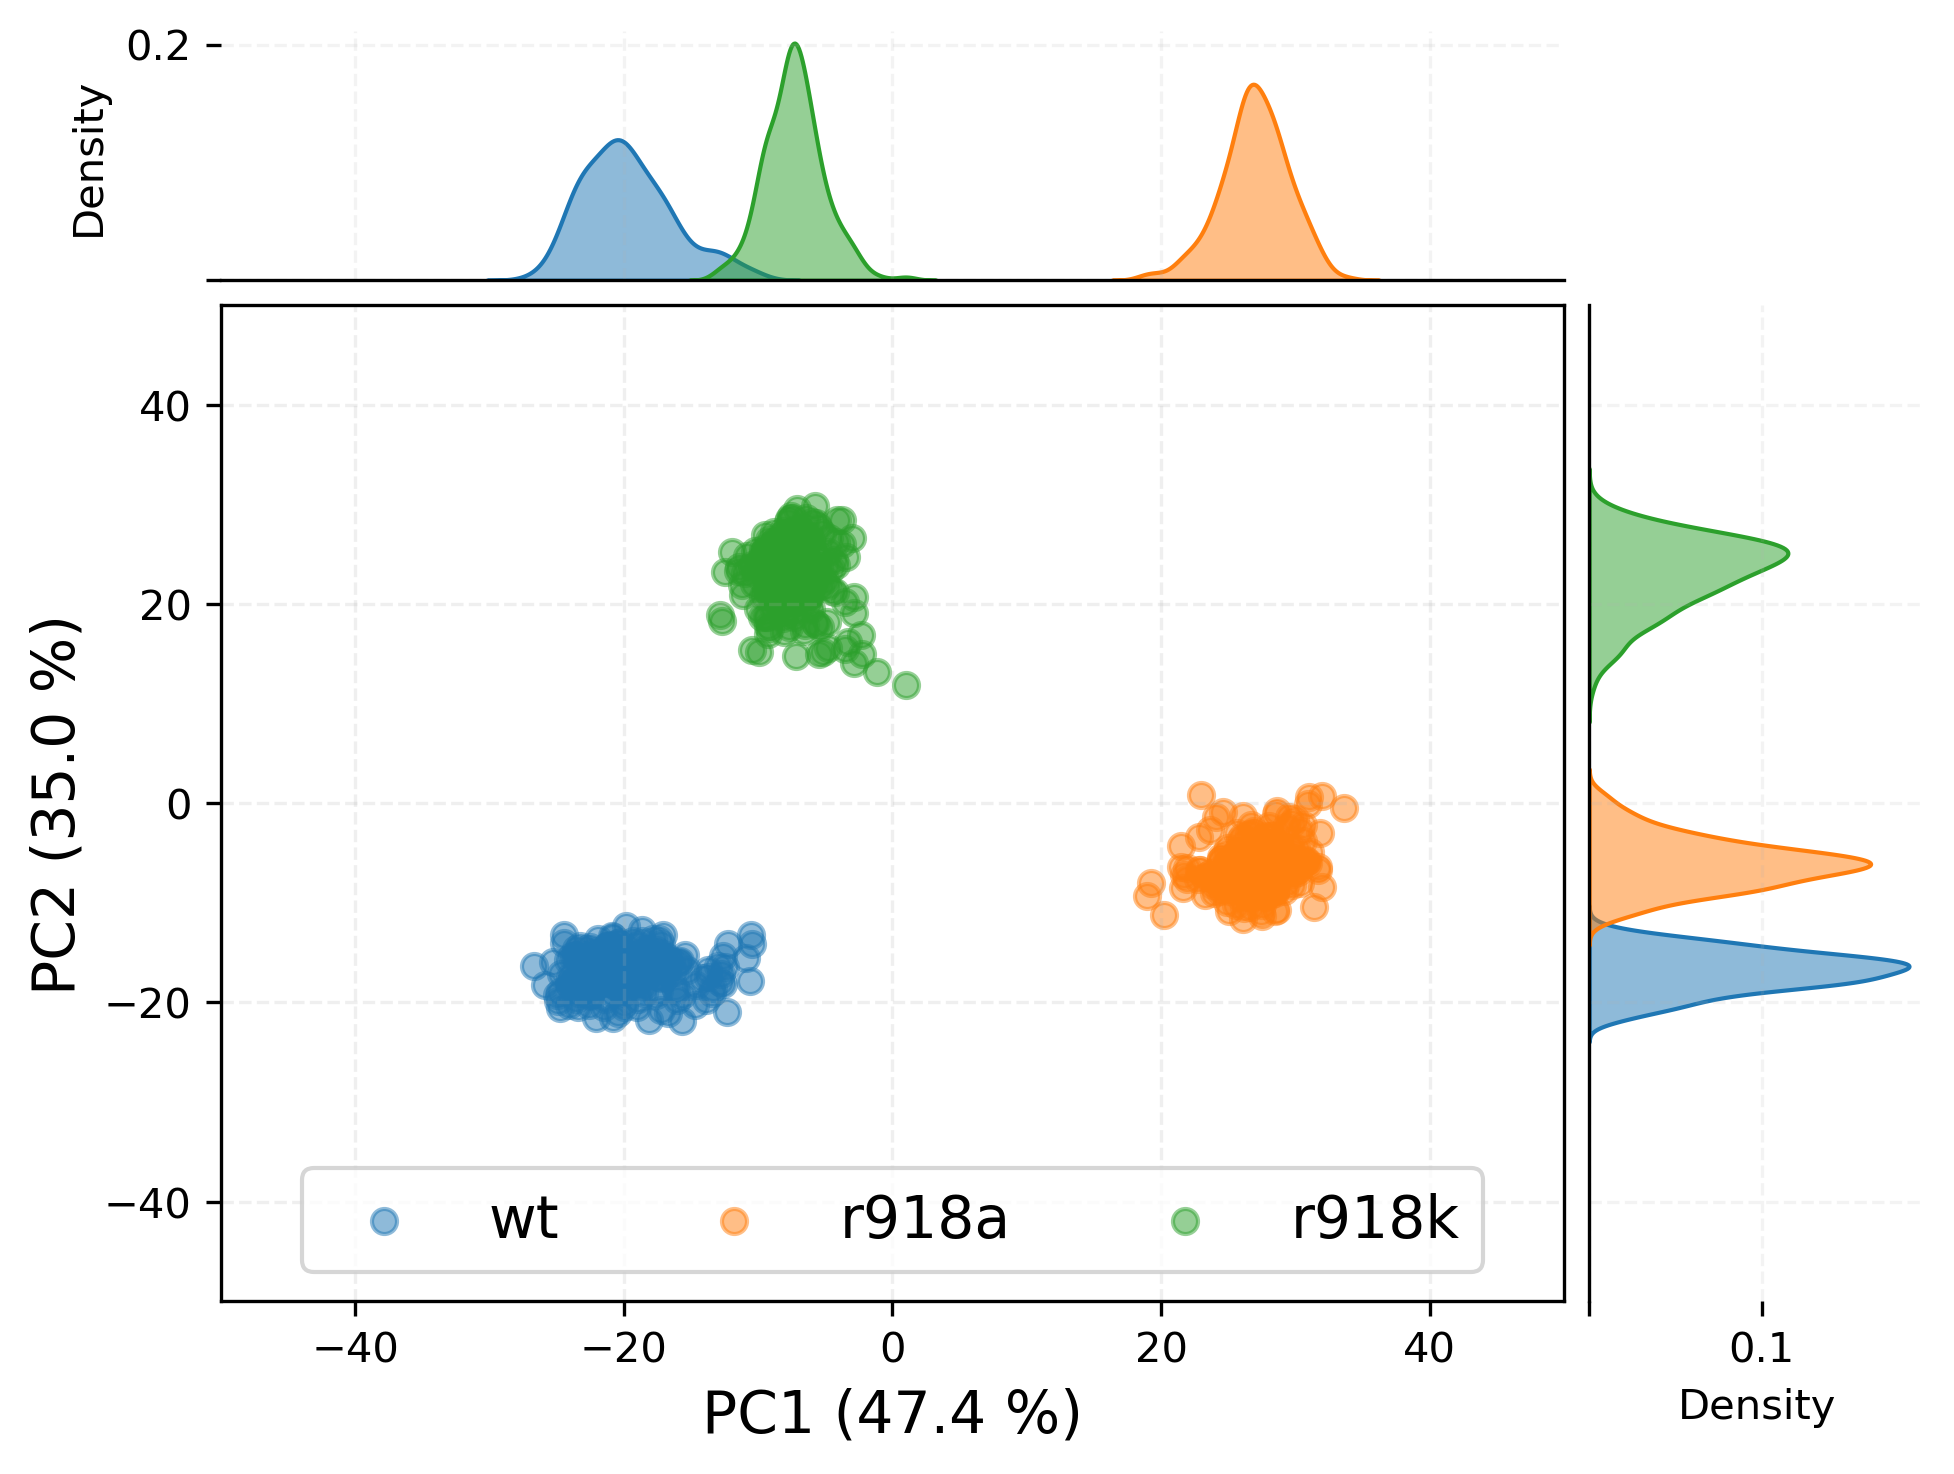

In [15]:
# Make figure

axis_lim = 50
opacity = 0.5
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig = plt.figure(dpi=300, constrained_layout=True)
#fig = plt.figure(figsize=(7.5, 7.5), dpi=300, constrained_layout=True)

gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), wspace=0.0, hspace=0.0)

ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# set range from i (first frame) to new_i (last frame for sys) 
i = 0
for ii, n in enumerate(label_idx):
    new_i = i + n
    xs = x_data[i:new_i]
    ys = y_data[i:new_i]

    ax.scatter(xs, ys, marker='o', c=colors[ii], alpha=opacity, label=dnames[ii])

    # KDE plot
    sb.kdeplot(x=xs, fill=True, common_norm=True, common_grid=True, ax=ax_histx, alpha=opacity)
    sb.kdeplot(y=ys, fill=True, common_norm=True, common_grid=True, ax=ax_histy, alpha=opacity)

    i = new_i # update i


ax_histx.tick_params(axis='x', labelbottom=False, bottom=False)  # top panel: hide x labels
ax_histy.tick_params(axis='y', labelleft=False, left=False)      # right panel: hide y labels
# ax.tick_params(axis='x', labelrotation=45)
# ax_histy.tick_params(axis='x', labelrotation=45)

# ax_histx: remove 0.00 on density (y)
base_y = ax_histx.yaxis.get_major_formatter()
ax_histx.yaxis.set_major_formatter(FuncFormatter(lambda v, p: "" if np.isclose(v, 0.0) else base_y(v, p)))

# ax_histy: remove 0.00 on density (x)
base_x = ax_histy.xaxis.get_major_formatter()
ax_histy.xaxis.set_major_formatter(FuncFormatter(lambda v, p: "" if np.isclose(v, 0.0) else base_x(v, p)))

# remove lines in subplots
ax_histx.spines['top'].set_visible(False)
ax_histx.spines['right'].set_visible(False)
ax_histx.spines['left'].set_visible(False)

ax_histy.spines['top'].set_visible(False)
ax_histy.spines['right'].set_visible(False)
ax_histy.spines['bottom'].set_visible(False)


ax.set_xlabel(f"PC1 ({np.round(x_label, 1)} %)", fontsize=14)
ax.set_ylabel(f"PC2 ({np.round(y_label, 1)} %)", fontsize=14)
ax.set_xlim(-axis_lim, axis_lim)
ax.set_ylim(-axis_lim, axis_lim)
ax.grid(linestyle='--', alpha=0.2)
ax.legend(ncols=3, loc='lower center', fontsize=14)

# optional: light grids for marginals too
ax_histx.grid(linestyle='--', alpha=0.15)
ax_histy.grid(linestyle='--', alpha=0.15)

plt.savefig(f'img/{dn}_{nframes}{analysis}.png')


In [16]:
# run cpptraj to get NMD and NC files for PCs

text = f"""
parm {combined_name}.parm7
trajin {combined_name}.nc

rms first {atm_mask}
average crdset step3-average
createcrd step3-trajectories
run

crdaction step3-trajectories rms ref step3-average {atm_mask}
crdaction step3-trajectories matrix covar name step3-covar {atm_mask}

runanalysis diagmatrix step3-covar out {combine_out}/step3-evecs.dat \
  vecs {n_vectors} name myEvecs \
  nmwiz nmwizvecs {n_vectors} nmwizfile {combine_out}/step3.nmd nmwizmask {atm_mask}

runanalysis modes name myEvecs trajout {combine_out}/step3-mode1.nc \
  pcmin -{axis_lim} pcmax {axis_lim} tmode 1 trajoutmask {atm_mask} trajoutfmt netcdf

runanalysis modes name myEvecs trajout {combine_out}/step3-mode2.nc \
  pcmin -{axis_lim} pcmax {axis_lim} tmode 2 trajoutmask {atm_mask} trajoutfmt netcdf
"""

state = pt.load_batch(traj, text)
state.run()


CpptrajState, include:
<datasetlist: 8 datasets>